In [1]:
import os
import shutil

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

import kagglehub
import tensorflow as tf
import keras as kb

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
path = "/root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/2"
if os.path.exists(path):
    shutil.rmtree(path)

path = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
print("Path to dataset files:", path)

100%|██████████| 86.8M/86.8M [00:03<00:00, 24.0MB/s]

Extracting files...


Path to dataset files: /Users/carolinerobinson/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/2


In [2]:
path = "/root/.cache/kagglehub/datasets/sartajbhuvaji/brain-tumor-classification-mri/versions/2"

train_dir = f"{path}/Training"
test_dir = f"{path}/Testing"

In [23]:
def move_images_with_copy_suffix(train_folder, test_folder):
    train_subfolders = os.listdir(train_folder)
    test_subfolders = os.listdir(test_folder)

    # ensure equivalent structure
    for test_subfolder in test_subfolders:
        if test_subfolder not in train_subfolders:
            print(f'No matching subfolder for {test_subfolder}')
            continue
        
        test_subfolder_path = os.path.join(test_folder, test_subfolder)
        train_subfolder_path = os.path.join(train_folder, test_subfolder)

        # loop through test images
        for image_name in os.listdir(test_subfolder_path):
            test_image_path = os.path.join(test_subfolder_path, image_name)
            
            if os.path.isfile(test_image_path):
                train_image_path = os.path.join(train_subfolder_path, image_name)
                
                # add a '_copy' instead of overwriting
                if os.path.exists(train_image_path):
                    name, ext = os.path.splitext(image_name)
                    new_image_name = name + "_copy" + ext
                    train_image_path = os.path.join(train_subfolder_path, new_image_name)
                
                # copy the image
                shutil.copy(test_image_path, train_image_path)

move_images_with_copy_suffix(train_dir, test_dir)

In [3]:
batch_size = 32
image_width = 150
image_height = 150

In [4]:
# train dataset
train_ds = kb.utils.image_dataset_from_directory(
    train_dir,
    seed=0,
    image_size=(image_width, image_height),
    batch_size=batch_size,
    label_mode='int',
    color_mode='grayscale',
    validation_split=0.2,
    subset='training'
)

# validation dataset
val_ds = kb.utils.image_dataset_from_directory(
    train_dir,
    seed=0,
    image_size=(image_width, image_height),
    batch_size=batch_size,
    label_mode='int',
    color_mode='grayscale',
    validation_split=0.2,
    subset='validation'
)

# make half of val ds the test ds
val_size = len(val_ds)
test_size = val_size // 2

test_ds = val_ds.take(test_size)
val_ds = val_ds.skip(test_size)

print(f"Taking half the files from validation for test.")

Found 3264 files belonging to 4 classes.
Using 2612 files for training.
Found 3264 files belonging to 4 classes.
Using 652 files for validation.
Taking half the files from validation for test.


In [26]:
# normalize images
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))
test_ds = test_ds.map(lambda x, y: (x / 255.0, y))

['no_tumor', 'meningioma_tumor', 'glioma_tumor', 'pituitary_tumor']


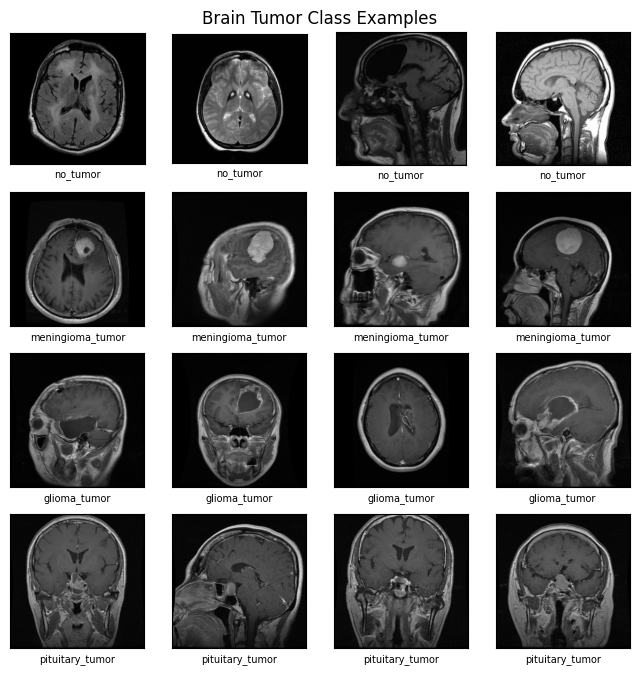

In [27]:
class_names = os.listdir(train_dir)[:4]
print(class_names)

plt.figure(figsize=(8, 8))
plt.title('Brain Tumor Class Examples')
plt.axis('off')

for i, class_name in enumerate(class_names):
    # path to each class
    class_dir = os.path.join(train_dir, class_name)

    if os.path.isdir(class_dir):
        # get images in each class dir
        image_files = [f for f in os.listdir(class_dir) if f.endswith(('jpg', 'jpeg', 'png'))]

        # 4 images a class
        for j, image_file in enumerate(image_files[:4]):
            image_path = os.path.join(class_dir, image_file)
            image = Image.open(image_path)

            # display images
            plt.subplot(4, 4, i * 4 + j + 1)
            plt.xticks([])
            plt.yticks([])
            plt.imshow(image)
            plt.xlabel(class_name, fontsize=7)

plt.show()

In [28]:
num_classes = 4

model = kb.Sequential([
    # data augmentation
    kb.layers.RandomFlip('horizontal', input_shape=(150, 150, 1)),
    kb.layers.RandomRotation(0.2),
    kb.layers.RandomZoom(0.2),

    # convolutional, pooling, and dropout
    kb.layers.Conv2D(32, (3, 3), activation='relu'),
    kb.layers.MaxPooling2D((2, 2)),

    kb.layers.Conv2D(64, (3, 3), activation='relu'),
    kb.layers.MaxPooling2D((2, 2)),
    kb.layers.Dropout(0.3),

    kb.layers.Conv2D(64, (3, 3), activation='relu'),
    kb.layers.Dropout(0.3),

    # fully connected layer
    kb.layers.Flatten(),
    kb.layers.Dense(128, activation='relu'),
    kb.layers.Dropout(0.5),
    kb.layers.Dense(num_classes, activation='softmax'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 150, 150, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     9,470,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,526,340 (36.34 MB)

 Trainable params: 9,526,340 (36.34 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, mode='min', verbose=1)

model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stopping])

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.3316 - loss: 1.3686 - val_accuracy: 0.3916 - val_loss: 1.2732
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.4553 - loss: 1.2240 - val_accuracy: 0.5602 - val_loss: 1.0757
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.5116 - loss: 1.1250 - val_accuracy: 0.6205 - val_loss: 0.9640
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.5449 - loss: 1.0598 - val_accuracy: 0.6295 - val_loss: 0.9418
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.5876 - loss: 0.9837 - val_accuracy: 0.6476 - val_loss: 0.7712
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.5758 - loss: 0.9613 - val_accuracy: 0.6777 - val_loss: 0.8262
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.6235 - loss: 0.9147 - val_accuracy: 0.6958 - val_loss: 0.7457
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.6090 - loss: 0.8968 - val_accu

In [6]:
# model.save('cnn_tumor.keras')

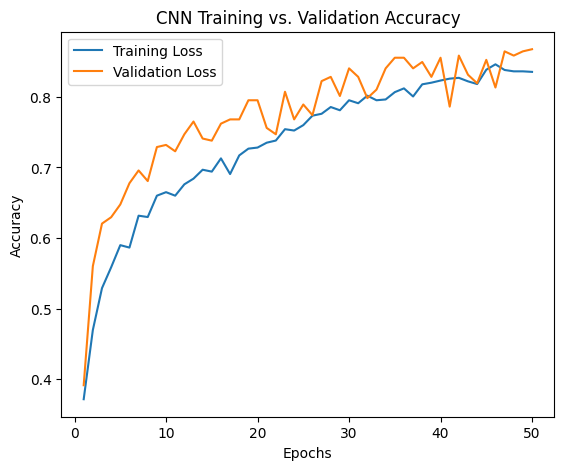

In [30]:
# plotting accuracy over epochs
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Training Loss')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Loss')
plt.title('CNN Training vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [31]:
train_loss, train_accuracy = model.evaluate(train_ds)
print(f"Train Loss: {train_loss}")
print(f"Train Accuracy: {train_accuracy}")

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8542 - loss: 0.3715
Train Loss: 0.3484307825565338
Train Accuracy: 0.8640888333320618
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8230 - loss: 0.4836
Test Loss: 0.4952956736087799
Test Accuracy: 0.8187500238418579


In [ ]:
# display random image and its predicted vs true value
def predict_rand_image(model, dir, ds):
  class_names = sorted(os.listdir(dir))

  # random image
  image_batch, label_batch = next(iter(ds))
  random_index = np.random.randint(0, len(image_batch))
  random_image = image_batch[random_index]
  random_image_batch = np.expand_dims(random_image, axis=0)

  # true label
  true_label = label_batch[random_index]
  true_label_int = true_label.numpy()
  true_label_class = class_names[true_label_int]

  # predicted label
  predicted_class_probabilities = model.predict(random_image_batch)
  predicted_class_index = np.argmax(predicted_class_probabilities)
  predicted_class = class_names[predicted_class_index]

  return random_image, true_label_class, predicted_class

# display for 10 ranfom images
for i in range(10):
  random_image, true_label_class, predicted_class = predict_rand_image(model, train_dir, test_ds)

  plt.figure(figsize=(6, 6))
  plt.imshow(random_image)
  plt.axis('off')
  plt.title(f"True Label: {true_label_class}\nPredicted: {predicted_class}")

  plt.show()